# HCMUT EE MACHINE LEARNING & IOT
## BTVN Buổi 1: Đại số tuyến tính cho AI

Môn học: Python & Machine Learning

Sinh viên: Nguyễn Bá Quốc Long

MSSV: 2550137


### Lựa chọn dữ liệu

Tôi lựa chọn text và chỉ sử dụng thư viện Numpy và Matplotlib cho cả hai bài

In [399]:
import numpy as np
import matplotlib.pyplot as plt

### Bài 1 - Biểu diễn dữ liệu thành ma trận & độ tương đồng

#### Biến dữ liệu thành ma trận

In [400]:
cau = [# --- Chủ đề 1: Công nghệ & Trí tuệ Nhân tạo ---
    "Trí tuệ nhân tạo đang thay đổi cách chúng ta làm việc mỗi ngày.",
    "Học máy giúp máy tính tự học hỏi từ dữ liệu thực tế mà không cần lập trình rõ ràng.",
    "Mô hình ngôn ngữ lớn có khả năng hiểu và tạo văn bản giống như con người.",
    "Mạng neural nhân tạo mô phỏng lại cách hoạt động của các neuron trong bộ não.",
    "Xử lý ngôn ngữ tự nhiên là một lĩnh vực đầy thách thức của AI.",
    "Tìm kiếm ngữ nghĩa thông minh hơn việc tìm kiếm dựa trên từ khóa thông thường.",
    "Thư viện Numpy và Matplotlib là trợ thủ đắc lực cho việc xử lý và trực quan hóa dữ liệu.",

    # --- Chủ đề 2: Học tập & Đời sống sinh viên ---
    "Cấu trúc dữ liệu và giải thuật là nền tảng cốt lõi của mọi lập trình viên.",
    "Tôi đang cố gắng tối ưu hóa phương pháp tự học để đạt kết quả tốt hơn.",
    "Luyện tập giải thuật trên các nền tảng giúp tư duy logic nhạy bén hơn.",
    "Kỳ quân sự là một trong những kỷ niệm đáng nhớ nhất của thời sinh viên.",
    "Làm việc nhóm hiệu quả giúp giải quyết bài toán lớn nhanh hơn làm việc cá nhân.",
    "Việc cân bằng giữa học tập và các hoạt động câu lạc bộ đòi hỏi kỹ năng quản lý thời gian.",
    "Đọc sách và tài liệu chuyên ngành giúp mở rộng thế giới quan mỗi ngày.",

    # --- Chủ đề 3: Ẩm thực Sài Gòn & Đời sống ---
    "Cơm tấm là món ăn đặc sản bình dân nhưng cực kỳ nổi tiếng tại Sài Gòn.",
    "Một ly cà phê sữa đá buổi sáng giúp tôi tỉnh táo và tập trung làm việc.",
    "Bánh mì Sài Gòn vừa tiện lợi vừa mang hương vị đặc trưng không lẫn vào đâu được.",
    "Tìm kiếm các món ăn ít calo là xu hướng của nhiều bạn trẻ hiện nay.",
    "Hủ tiếu gõ là nét văn hóa ẩm thực đêm quen thuộc của người dân thành phố.",
    "Thưởng thức một bát bún riêu cua đồng vào ngày mưa là trải nghiệm rất tuyệt vời."]
vocab = sorted({w for s in cau for w in s.lower().split()})
def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        v[vocab.index(w)] += 1
    return v
X = np.array([to_vector(s) for s in cau])
so_cau = X.shape[0]
so_tu_khac_biet = X.shape[1]
print(X.shape)


(20, 234)


##### Mỗi hàng/cột đại diện cho gì?
* Mỗi hàng đại diện cho mỗi câu trong tập dữ liệu.
  * Ví dụ: Ở hàng 3 (tức câu "Bạn đang làm gì vậy"), các từ "Bạn", "đang", "làm", "gì", "vậy" xuất hiện 1 lần, các từ còn lại không xuất hiện.
* Mỗi cột đại diện cho số lần mỗi từ xuất hiện và lặp lại (nếu có) ở các câu.
  * Ví dụ: Ở cột 1 (tức từ "ai"), nó chỉ xuất hiện 1 lần ở câu cuối, không xuất hiện ở các câu còn lại.

#### Phép toán cơ bản

In [401]:
mean = X.mean(axis=0)
Y = X - mean
print(Y.shape)

(20, 234)


#### Cosine similarity

In [402]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T

#### Truy vấn

In [403]:
def search(query, top_k=3):
    q = np.array(to_vector(query).reshape(1, so_tu_khac_biet))
    sims = cosine_similarity(X, q).flatten()
    idx = np.argsort(sims)[-top_k:][::-1]
    return [(cau[i], round(float(sims[i]), 3)) for i in idx]
print(search("Ẩm thực"))

[('Hủ tiếu gõ là nét văn hóa ẩm thực đêm quen thuộc của người dân thành phố.', 0.343), ('Học máy giúp máy tính tự học hỏi từ dữ liệu thực tế mà không cần lập trình rõ ràng.', 0.144), ('Thưởng thức một bát bún riêu cua đồng vào ngày mưa là trải nghiệm rất tuyệt vời.', 0.0)]


#### Nhận xét

##### Cặp nào giống nhau nhất, cặp nào khác biệt nhất?
* Cặp giống nhau nhất là cặp mà có số đo cosine similarity gần bằng 1 nhất.
* Cặp khác biệt nhất là cặp mà có số đo cosine similarity bằng 0 hoặc nhỏ nhất trong các cặp.
##### Kết quả có khớp trực giác không?


### Bài 2 - Biến đổi tuyến tính & SVD

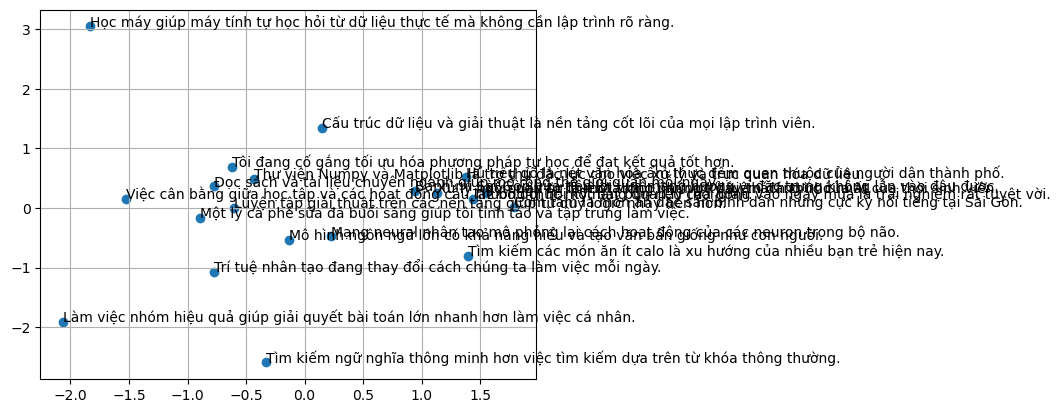

In [404]:
Xc = X - X.mean(axis =0) # center du lieu
U, S, Vt = np.linalg.svd(Xc , full_matrices=False)
coords = U[:, :2] * S[:2]
x_coor = coords[0:,0]
y_coor = coords[0:,1]
plt.scatter(x_coor, y_coor)
for ind, label in enumerate(cau):
    plt.annotate(cau[ind], (x_coor[ind], y_coor[ind]))
plt.grid()
plt.show()